
Spline S0:
a0 = 1
b0 = 7.0
c0 = 0
d0 = -3.0
S0(x) = 1 + (7.0)(x + 1) + (0)(x + 1)^2 + (-3.0)(x + 1)^3

Spline S1:
a1 = 5
b1 = -2
c1 = 0.0
d1 = 0.0
S1(x) = 5 + (-2)(x) + (0.0)(x)^2 + (0.0)(x)^3


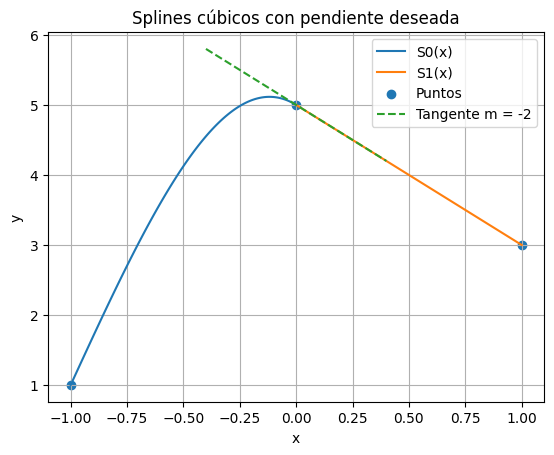

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


def Spline(x, x0, pars):

    a = pars["a"]
    b = pars["b"]
    c = pars["c"]
    d = pars["d"]

    return (
        a
        + b * (x - x0)
        + c * (x - x0) ** 2
        + d * (x - x0) ** 3
    )


def calcular_splines(m):

    spline_0 = {
        "a": 1,
        "b": 6 - m / 2,
        "c": 0,
        "d": (m - 4) / 2
    }


    spline_1 = {
        "a": 5,
        "b": m,
        "c": -3 * (m + 2) / 2,
        "d": (m + 2) / 2
    }

    return [spline_0, spline_1]


def mostrar_splines(splines):


    for i, spline in enumerate(splines):
        a = spline["a"]
        b = spline["b"]
        c = spline["c"]
        d = spline["d"]

        print(f"\nSpline S{i}:")

        print(f"a{i} = {a}")
        print(f"b{i} = {b}")
        print(f"c{i} = {c}")
        print(f"d{i} = {d}")

        if i == 0:
            print(
                f"S0(x) = {a} + ({b})(x + 1)"
                f" + ({c})(x + 1)^2"
                f" + ({d})(x + 1)^3"
            )
        else:
            print(
                f"S1(x) = {a} + ({b})(x)"
                f" + ({c})(x)^2"
                f" + ({d})(x)^3"
            )


# Puntos de interpolación
xs = [-1, 0, 1]
ys = [1, 5, 3]

# Pendiente
m = -2

# Calcula los splines
s = calcular_splines(m)

mostrar_splines(s)

for i, x_i in enumerate(xs[:-1]):
    _x = np.linspace(x_i, xs[i + 1], 100)
    _y = Spline(_x, x_i, s[i])

    plt.plot(
        _x,
        _y,
        label=f"S{i}(x)"
    )

plt.scatter(xs, ys, label="Puntos")

# Grafica la tangente
x_tangente = np.linspace(-0.4, 0.4, 50)
y_tangente = 5 + m * x_tangente

plt.plot(
    x_tangente,
    y_tangente,
    linestyle="--",
    label=f"Tangente m = {m}"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Splines cúbicos con pendiente deseada")
plt.grid(True)
plt.legend()
plt.show()